In [ ]:
from __future__ import annotations

import argparse
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
from pyimzml.ImzMLParser import ImzMLParser
from __future__ import annotations

import argparse
from dataclasses import dataclass, asdict
from io import StringIO
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from scipy.signal import find_peaks, savgol_filter
import random
import matplotlib.pyplot as plt

/p1/zulab_users/jtian/anaconda3/envs/my_NewSA_py39/lib/python3.9/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


pixel index: 11577
coord: (195, 80, 1)
点数: 1791
前10个 m/z: [58.03044983 59.01418593 67.01910572 68.01326267 68.99801336 69.03459197
 70.00647229 70.02992837 71.01369076 71.05062745]
m/z 间隔统计:
  min = 0.0
  max = 23.054046342734296
  median = 0.11156340857421299


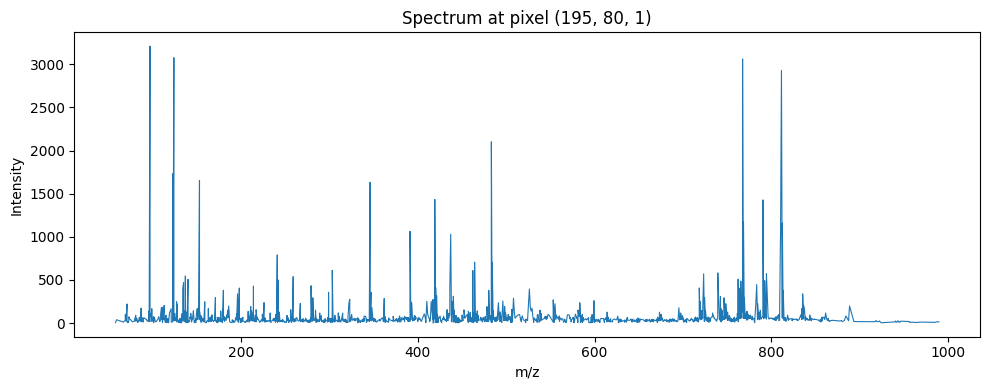

In [4]:
# 你的 imzML 文件路径
imzml_path = "/p2/zulab/jtian/data/SA/03_removeLow-qualityPeaks/imzML/01.imzML"

parser = ImzMLParser(imzml_path)

idx = random.randrange(len(parser.coordinates))
coord = parser.coordinates[idx]
mzs, intensities = parser.getspectrum(idx)

print("pixel index:", idx)
print("coord:", coord)
print("点数:", len(mzs))
print("前10个 m/z:", mzs[:10])

dmz = np.diff(mzs)
print("m/z 间隔统计:")
print("  min =", dmz.min())
print("  max =", dmz.max())
print("  median =", np.median(dmz))

plt.figure(figsize=(10, 4))
plt.plot(mzs, intensities, lw=0.8)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Spectrum at pixel {coord}")
plt.tight_layout()
plt.show()


In [6]:
import xml.etree.ElementTree as ET

imzml_path = "/p2/zulab/jtian/data/SA/03_removeLow-qualityPeaks/imzML/01.imzML"

tree = ET.parse(imzml_path)
root = tree.getroot()

profile_hits = []
centroid_hits = []

for elem in root.iter():
    accession = elem.attrib.get("accession", "")
    name = elem.attrib.get("name", "")
    if accession == "MS:1000128" or name.lower() == "profile spectrum":
        profile_hits.append(elem.attrib)
    if accession == "MS:1000127" or name.lower() == "centroid spectrum":
        centroid_hits.append(elem.attrib)

print("profile:", profile_hits)
print("centroid:", centroid_hits)


profile: []
centroid: [{'accession': 'MS:1000127', 'cvRef': 'MS', 'name': 'centroid spectrum'}]
